# Model Evaluation and Prediction Examples

This notebook reviews saved V5 results and runs example predictions through the project predictor.

It uses the saved model file from:

```text
models/match_edge_ai_v5_calibrated_specialist_ensemble.pkl
```

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from match_edge_v5_predictor import MatchEdgeV5Predictor

DATA_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports"

In [2]:
metrics = pd.read_csv(REPORT_DIR / "model_metrics.csv")
weights = pd.read_csv(REPORT_DIR / "optimized_blend_weights.csv")

metrics

,model,scenario,role,accuracy,log_loss,base_train_rows,blend_train_rows,test_rows
0,optimized_weighted_blend_calibrated,optimized blend plus temperature calibration,final,0.6013,0.8712,4295,1042,153
1,optimized_weighted_blend_raw,optimized blend before calibration,final,0.6013,0.8740,4295,1042,153
2,strength_elo_logistic,overall team strength,specialist,0.6144,0.8688,4295,1042,153
3,full_xgboost,full nonlinear 1X2,specialist,0.5948,0.8724,4295,1042,153
4,draw_risk_classifier,draw risk,specialist,0.5882,0.8788,4295,1042,153
5,poisson_scoreline_model,expected score / scoreline,specialist,0.5817,0.8819,4295,1042,153
6,recent_form_random_forest,recent form,specialist,0.5359,0.9410,4295,1042,153
7,context_xgboost,match context,specialist,0.5033,1.0012,4295,1042,153


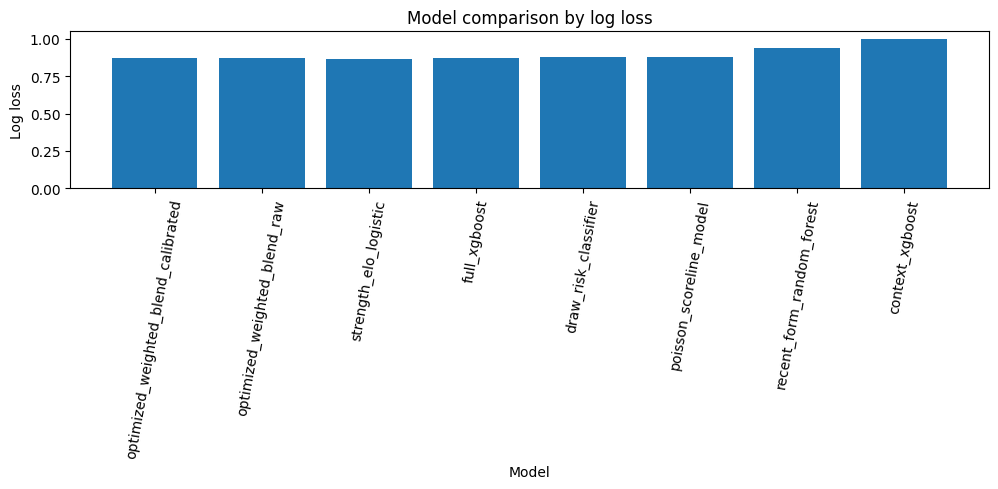

In [3]:
plt.figure(figsize=(10, 5))
plt.bar(metrics["model"], metrics["log_loss"])
plt.title("Model comparison by log loss")
plt.xlabel("Model")
plt.ylabel("Log loss")
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

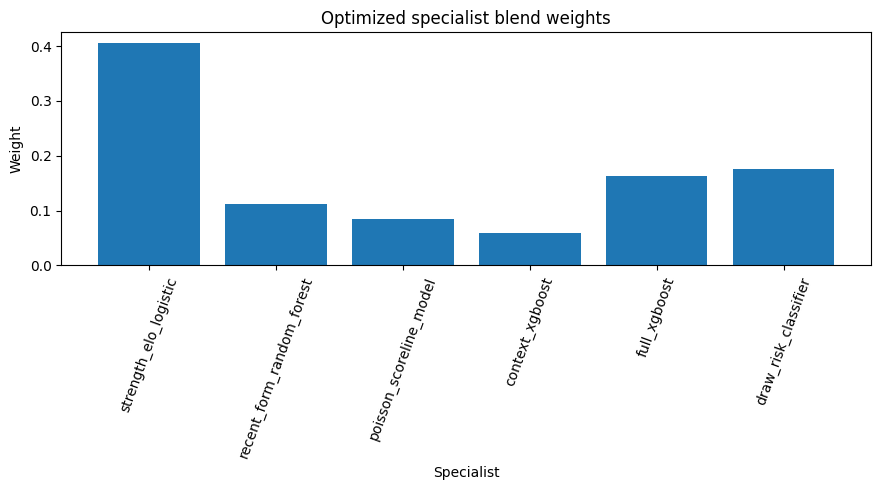

,specialist,optimized_weight
0,strength_elo_logistic,0.404705
1,recent_form_random_forest,0.111795
2,poisson_scoreline_model,0.085487
3,context_xgboost,0.059879
4,full_xgboost,0.162845
5,draw_risk_classifier,0.175289


In [4]:
plt.figure(figsize=(9, 5))
plt.bar(weights["specialist"], weights["optimized_weight"])
plt.title("Optimized specialist blend weights")
plt.xlabel("Specialist")
plt.ylabel("Weight")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

weights

In [5]:
predictor = MatchEdgeV5Predictor(
    teams_csv=DATA_DIR / "wc2026_teams_model_input.csv",
    features_csv=DATA_DIR / "team_form_elo_latest.csv",
    model_path=MODEL_DIR / "match_edge_ai_v5_calibrated_specialist_ensemble.pkl",
)

predictor.valid_teams().head()

,team_id,team_name,group_code,confederation,fifa_rank,fifa_points,current_elo
3,CZE,Czechia,A,UEFA,40,1505.74,1599.61
2,KOR,Korea Republic,A,AFC,25,1591.63,1789.19
0,MEX,Mexico,A,CONCACAF,14,1687.48,1834.39
1,RSA,South Africa,A,CAF,60,1428.38,1621.19
5,BIH,Bosnia and Herzegovina,B,UEFA,64,1387.22,1485.30


In [6]:
result = predictor.predict(
    "United States",
    "Paraguay",
    venue_country="United States",
    team_a_rest_days=5,
    team_b_rest_days=4,
    team_a_travel_km=0,
    team_b_travel_km=1200,
    temperature_c=24,
    humidity_pct=55,
)

summary = {
    key: value
    for key, value in result.items()
    if key != "specialist_breakdown"
}

pd.Series(summary)

team_a_id                                                                     USA
team_a_name                                                         United States
team_b_id                                                                     PAR
team_b_name                                                              Paraguay
venue_country                                                       United States
team_a_win_probability                                                     0.4356
draw_probability                                                           0.2841
team_b_win_probability                                                     0.2802
predicted_result                                                United States win
team_a_expected_goals                                                        1.44
team_b_expected_goals                                                        1.06
team_a_current_elo                                                        1696.25
team_b_current_e

In [7]:
breakdown = pd.DataFrame(result["specialist_breakdown"]).T
breakdown

,team_b_win_probability,draw_probability,team_a_win_probability,blend_weight
strength_elo_logistic,0.2754,0.3163,0.4084,0.4047
recent_form_random_forest,0.3286,0.2758,0.3956,0.1118
poisson_scoreline_model,0.2790,0.2646,0.4564,0.0855
context_xgboost,0.2888,0.2229,0.4883,0.0599
full_xgboost,0.3460,0.2862,0.3678,0.1628
draw_risk_classifier,0.3517,0.2745,0.3738,0.1753
fifa_rank_points_specialist_untrained,0.0770,0.2468,0.6762,0.0000


In [8]:
examples = [
    ("Mexico", "South Africa", "Mexico"),
    ("Canada", "Bosnia and Herzegovina", "Canada"),
    ("United States", "Paraguay", "United States"),
    ("Brazil", "Morocco", "Other"),
    ("Spain", "Uruguay", "Other"),
]

rows = []

for team_a, team_b, venue_country in examples:
    output = predictor.predict(team_a, team_b, venue_country=venue_country)
    rows.append({
        "match": f"{output['team_a_name']} vs {output['team_b_name']}",
        "team_a_win_probability": output["team_a_win_probability"],
        "draw_probability": output["draw_probability"],
        "team_b_win_probability": output["team_b_win_probability"],
        "predicted_result": output["predicted_result"],
        "expected_score": f"{output['team_a_expected_goals']} - {output['team_b_expected_goals']}",
    })

pd.DataFrame(rows)

,match,team_a_win_probability,draw_probability,team_b_win_probability,predicted_result,expected_score
0,Mexico vs South Africa,0.6698,0.2069,0.1233,Mexico win,1.87 - 0.7
1,Canada vs Bosnia and Herzegovina,0.6869,0.2030,0.1101,Canada win,1.68 - 0.71
2,United States vs Paraguay,0.4074,0.2870,0.3057,United States win,1.44 - 1.06
3,Brazil vs Morocco,0.3200,0.3065,0.3736,Morocco win,1.01 - 1.44
4,Spain vs Uruguay,0.6978,0.2105,0.0917,Spain win,2.16 - 0.66
